# Bound-Retention Model Training

This notebook trains and evaluates ML models for predicting simulation outcomes.

## Structure

1. **Classification gate** – Can the model predict whether `bound_mass_fraction ≥ 10%`? If yes, we do not need separate `has_any_bound_mass` or `BMF ≥ 10%` classification targets downstream.
2. **Fragmentation regression** – Three targets describing the fragmentation outcome:
   - `n_fragments` — total fragment count
   - `largest_fragment_mass_kg` — mass of the largest fragment overall
   - `total_fragment_mass_kg` — total mass in all fragments
3. **Bound regression** – Four targets describing the bound-retention outcome:
   - `bound_mass_fraction` — fraction of target mass that is gravitationally bound
   - `bound_fragment_count` — number of bound fragments
   - `largest_bound_fragment_mass_kg` — mass of the largest bound fragment
   - `average_bound_fragment_mass_kg` — mean mass per bound fragment

## 0 · Imports and configuration

In [1]:
from __future__ import annotations

import pickle
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    mean_absolute_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
N_SPLITS = 5

DATASET_PATH = Path("outputs/bound_outcomes.csv")
SAVE_DIR = Path("ml/bound_outcomes/notebook_demo")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ── Classification gate ───────────────────────────────────────────────────────
# Default target: bound_mass_fraction >= 10%.  If the models predict this well
# (e.g. ROC-AUC > 0.80) we can skip separate has_any_bound_mass and BMF≥10%
# classification targets and go straight to the regression tasks below.
CLASSIFICATION_TARGET = "bound_mass_fraction_ge_0_1"

# ── Regression targets ────────────────────────────────────────────────────────
FRAGMENTATION_TARGETS = [
    "n_fragments",
    "largest_fragment_mass_kg",   # engineered: max(largest_bound, largest_unbound)
    "total_fragment_mass_kg",
]

BOUND_TARGETS = [
    "bound_mass_fraction",
    "bound_fragment_count",
    "largest_bound_fragment_mass_kg",
    "average_bound_fragment_mass_kg",  # engineered: bound_mass_kg / bound_fragment_count
]

# ── Feature set ───────────────────────────────────────────────────────────────
FEATURE_COLUMNS = [
    "mass_log10_kg",
    "particle_log10",
    "periapsis_Rm",
    "v_inf_kms",
    "spin_period_hr",
    "spin_axis",
    "has_explicit_spin",
    "special_case_code",
    "timestep",
    "fof_linking_length",
]

plt.style.use("seaborn-v0_8-whitegrid")
print("Configuration ready.")

Configuration ready.


## 1 · Filename parser and feature engineering

In [2]:
FILENAME_RE = re.compile(
    r"^(?P<prefix>Ma_xp)_(?P<mass>A\d{4}(?:c30)?)(?:_(?P<spin>s\d{3}[A-Za-z]*))?_n(?P<resolution>\d+)"
    r"_r(?P<periapsis>\d+)_v(?P<velocity>\d+)_(?P<timestep>\d+)_fof_(?P<linking_length>[0-9.]+)_(?P<chunk>\d+)\.hdf5$"
)


def parse_simulation_filename(filename: str) -> dict[str, object]:
    match = FILENAME_RE.match(filename)
    if not match:
        raise ValueError(f"Unrecognized FoF filename pattern: {filename}")

    mass_code = match.group("mass")
    spin_code = match.group("spin") or ""
    special_case_code = "c30" if mass_code.endswith("c30") else ""
    mass_digits = mass_code[1:5]
    spin_axis = spin_code[4:] if len(spin_code) > 4 else ""
    spin_value = spin_code[1:4] if spin_code else ""

    return {
        "filename": filename,
        "mass_code": mass_code,
        "mass_value": int(mass_digits),
        "special_case_code": special_case_code,
        "spin_code": spin_code,
        "spin_value": int(spin_value) if spin_value else "",
        "spin_axis": spin_axis,
        "has_explicit_spin": bool(spin_code),
        "resolution_code": f"n{int(match.group('resolution'))}",
        "resolution_value": int(match.group("resolution")),
        "periapsis_value": int(match.group("periapsis")),
        "velocity_value": int(match.group("velocity")),
        "timestep": int(match.group("timestep")),
        "fof_linking_length": float(match.group("linking_length")),
        "chunk_index": int(match.group("chunk")),
    }


def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    frame = df.copy()
    parsed = frame["fof_file"].map(parse_simulation_filename).apply(pd.Series)
    for column in parsed.columns:
        if column not in frame.columns:
            frame[column] = parsed[column]

    # Numeric features
    frame["mass_log10_kg"] = pd.to_numeric(frame["mass_value"], errors="coerce") / 100.0
    resolution_values = pd.to_numeric(frame["resolution_value"], errors="coerce")
    frame["particle_log10"] = resolution_values.map(lambda x: np.nan if pd.isna(x) else np.log10(x))
    frame["periapsis_Rm"] = pd.to_numeric(frame["periapsis_value"], errors="coerce") / 10.0
    frame["v_inf_kms"] = pd.to_numeric(frame["velocity_value"], errors="coerce") / 10.0
    frame["spin_period_hr"] = pd.to_numeric(frame["spin_value"], errors="coerce") / 10.0
    frame["has_explicit_spin"] = (
        frame["has_explicit_spin"].fillna(False).astype(str).str.lower().isin({"true", "1", "yes"})
    )
    frame["spin_axis"] = frame["spin_axis"].fillna("none").replace("", "none")
    frame["special_case_code"] = frame["special_case_code"].fillna("").replace("", "none")

    # Classification target
    frame["bound_mass_fraction_ge_0_1"] = pd.to_numeric(frame["bound_mass_fraction"], errors="coerce") >= 0.1

    # Engineered regression targets
    bound_mass_kg = pd.to_numeric(frame["bound_mass_kg"], errors="coerce")
    bound_fragment_count = pd.to_numeric(frame["bound_fragment_count"], errors="coerce").replace(0, np.nan)
    frame["average_bound_fragment_mass_kg"] = bound_mass_kg / bound_fragment_count

    largest_bound = pd.to_numeric(frame["largest_bound_fragment_mass_kg"], errors="coerce").fillna(0)
    largest_unbound = pd.to_numeric(frame["largest_unbound_fragment_mass_kg"], errors="coerce").fillna(0)
    frame["largest_fragment_mass_kg"] = largest_bound.where(largest_bound >= largest_unbound, largest_unbound)

    return frame


print("Feature engineering functions defined.")

Feature engineering functions defined.


## 2 · Load and prepare data

In [3]:
raw_df = pd.read_csv(DATASET_PATH, low_memory=False)
df = add_engineered_features(raw_df)

X = df[FEATURE_COLUMNS].copy()
groups = df["physical_file"].astype(str)

summary_rows = []
for target in [CLASSIFICATION_TARGET] + FRAGMENTATION_TARGETS + BOUND_TARGETS:
    col = df[target] if target in df.columns else pd.Series(dtype=float)
    summary_rows.append({
        "target": target,
        "non_null": int(col.notna().sum()),
        "mean": round(float(col.mean()), 6) if pd.api.types.is_numeric_dtype(col) else None,
        "std": round(float(col.std()), 6) if pd.api.types.is_numeric_dtype(col) else None,
    })

pd.DataFrame(summary_rows)

,target,non_null,mean,std
0,bound_mass_fraction_ge_0_1,407,3.636360e-01,4.816380e-01
1,n_fragments,407,4.660049e+02,9.473416e+02
2,largest_fragment_mass_kg,407,2.756020e+19,4.545581e+19
3,total_fragment_mass_kg,407,8.640778e+19,1.222503e+20
4,bound_mass_fraction,407,7.910300e-02,9.316300e-02
5,bound_fragment_count,407,9.700000e+01,2.655358e+02
6,largest_bound_fragment_mass_kg,407,1.575954e+18,3.848265e+18
7,average_bound_fragment_mass_kg,225,2.003762e+17,2.576968e+17


## 3 · Preprocessing and model builders

In [4]:
CATEGORICAL_FEATURES = [c for c in ["spin_axis", "special_case_code"] if c in FEATURE_COLUMNS]
NUMERIC_FEATURES = [c for c in FEATURE_COLUMNS if c not in CATEGORICAL_FEATURES]


def build_preprocessor(scale: bool = False) -> ColumnTransformer:
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        numeric_steps.append(("scaler", StandardScaler()))
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline(numeric_steps), NUMERIC_FEATURES),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]),
                CATEGORICAL_FEATURES,
            ),
        ]
    )


def build_classifiers() -> dict[str, Pipeline]:
    return {
        "logistic_regression": Pipeline([
            ("preprocessor", build_preprocessor(scale=True)),
            ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
        ]),
        "random_forest": Pipeline([
            ("preprocessor", build_preprocessor()),
            ("model", RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                              class_weight="balanced_subsample",
                                              random_state=RANDOM_STATE, n_jobs=-1)),
        ]),
        "gradient_boosting": Pipeline([
            ("preprocessor", build_preprocessor()),
            ("model", GradientBoostingClassifier(random_state=RANDOM_STATE)),
        ]),
    }


def build_regressors() -> dict[str, Pipeline]:
    return {
        "ridge": Pipeline([
            ("preprocessor", build_preprocessor(scale=True)),
            ("model", Ridge(random_state=RANDOM_STATE)),
        ]),
        "random_forest": Pipeline([
            ("preprocessor", build_preprocessor()),
            ("model", RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                                             random_state=RANDOM_STATE, n_jobs=-1)),
        ]),
        "gradient_boosting": Pipeline([
            ("preprocessor", build_preprocessor()),
            ("model", GradientBoostingRegressor(random_state=RANDOM_STATE)),
        ]),
    }


print("Model builders ready.")

Model builders ready.


## 4 · Evaluation helpers

In [5]:
def clf_metrics(y_true, y_pred, y_score):
    m = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }
    m["roc_auc"] = float(roc_auc_score(y_true, y_score)) if y_score is not None and pd.Series(y_true).nunique() > 1 else np.nan
    return m


def reg_metrics(y_true, y_pred):
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true, y_pred = np.array(y_true)[mask], np.array(y_pred)[mask]
    return {
        "r2": float(r2_score(y_true, y_pred)),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "n": int(len(y_true)),
    }


def evaluate_classifier(name, base_pipeline, X, y, groups):
    splitter = GroupKFold(n_splits=min(N_SPLITS, groups.nunique()))
    y_pred = pd.Series(index=y.index, dtype="bool")
    y_score = pd.Series(index=y.index, dtype="float64")

    for train_idx, test_idx in splitter.split(X, y, groups):
        pipeline = clone(base_pipeline)
        pipeline.fit(X.iloc[train_idx], y.iloc[train_idx])
        y_pred.iloc[test_idx] = pipeline.predict(X.iloc[test_idx]).astype(bool)
        y_score.iloc[test_idx] = pipeline.predict_proba(X.iloc[test_idx])[:, 1]

    oof_metrics = clf_metrics(y, y_pred.astype(bool), y_score.to_numpy())

    final = clone(base_pipeline)
    final.fit(X, y)
    train_metrics = clf_metrics(y, final.predict(X).astype(bool), final.predict_proba(X)[:, 1])

    row = {"model": name, **oof_metrics, **{f"train_{k}": v for k, v in train_metrics.items()}}
    preds = pd.DataFrame({"actual": y.astype(bool), "predicted": y_pred.astype(bool), "score": y_score})
    return row, preds, final


def evaluate_regressor(name, base_pipeline, X, y, groups):
    splitter = GroupKFold(n_splits=min(N_SPLITS, groups.nunique()))
    y_pred = pd.Series(np.nan, index=y.index, dtype="float64")

    valid_mask = y.notna()
    X_v, y_v, g_v = X[valid_mask], y[valid_mask], groups[valid_mask]

    for train_idx, test_idx in splitter.split(X_v, y_v, g_v):
        pipeline = clone(base_pipeline)
        pipeline.fit(X_v.iloc[train_idx], y_v.iloc[train_idx])
        y_pred.iloc[valid_mask.values.nonzero()[0][test_idx]] = pipeline.predict(X_v.iloc[test_idx])

    oof_metrics = reg_metrics(y_v.to_numpy(), y_pred[valid_mask].to_numpy())

    final = clone(base_pipeline)
    final.fit(X_v, y_v)
    train_pred = final.predict(X_v)
    train_metrics = reg_metrics(y_v.to_numpy(), train_pred)

    row = {"model": name, **oof_metrics, **{f"train_{k}": v for k, v in train_metrics.items()}}
    preds = pd.DataFrame({"actual": y_v, "predicted": y_pred[valid_mask]})
    return row, preds, final


print("Evaluation helpers ready.")

Evaluation helpers ready.


---
## 5 · Classification gate: can we predict BMF ≥ 10%?

**Goal**: Confirm that `bound_mass_fraction ≥ 0.1` is predictable from simulation inputs.  
If ROC-AUC > 0.80 on out-of-fold predictions, we do not need separate `has_any_bound_mass` or `BMF ≥ 10%` classification targets — one well-performing classifier is sufficient.

In [6]:
y_clf = df[CLASSIFICATION_TARGET].astype(bool)

print(f"Target: {CLASSIFICATION_TARGET}")
print(f"  Total rows   : {len(y_clf)}")
print(f"  Positive rate: {y_clf.mean():.3f}")

classifiers = build_classifiers()
clf_rows, clf_preds, clf_trained = [], {}, {}

for model_name, pipeline in classifiers.items():
    print(f"  Training {model_name} …")
    row, preds, fitted = evaluate_classifier(model_name, pipeline, X, y_clf, groups)
    clf_rows.append(row)
    clf_preds[model_name] = preds
    clf_trained[model_name] = fitted

clf_metrics_df = pd.DataFrame(clf_rows).sort_values(["roc_auc", "balanced_accuracy"], ascending=False)
best_clf_name = clf_metrics_df.iloc[0]["model"]
best_roc = clf_metrics_df.iloc[0]["roc_auc"]

print(f"\nBest classifier : {best_clf_name}  (OOF ROC-AUC = {best_roc:.3f})")
gate_passed = best_roc > 0.80
print(f"Gate passed (AUC > 0.80): {'YES — skip redundant targets 1 & 2' if gate_passed else 'NO — consider keeping them'}")
clf_metrics_df[[
    "model", "balanced_accuracy", "f1", "roc_auc",
    "train_balanced_accuracy", "train_f1", "train_roc_auc"
]]

Target: bound_mass_fraction_ge_0_1
  Total rows   : 407
  Positive rate: 0.364
  Training logistic_regression …
  Training random_forest …


  Training gradient_boosting …

Best classifier : random_forest  (OOF ROC-AUC = 0.992)
Gate passed (AUC > 0.80): YES — skip redundant targets 1 & 2


,model,balanced_accuracy,f1,roc_auc,train_balanced_accuracy,train_f1,train_roc_auc
1,random_forest,0.949324,0.930693,0.992330,0.989382,0.986486,0.999583
2,gradient_boosting,0.961873,0.947020,0.989917,0.992761,0.989899,0.999609
0,logistic_regression,0.916023,0.884615,0.972608,0.924710,0.894569,0.978634


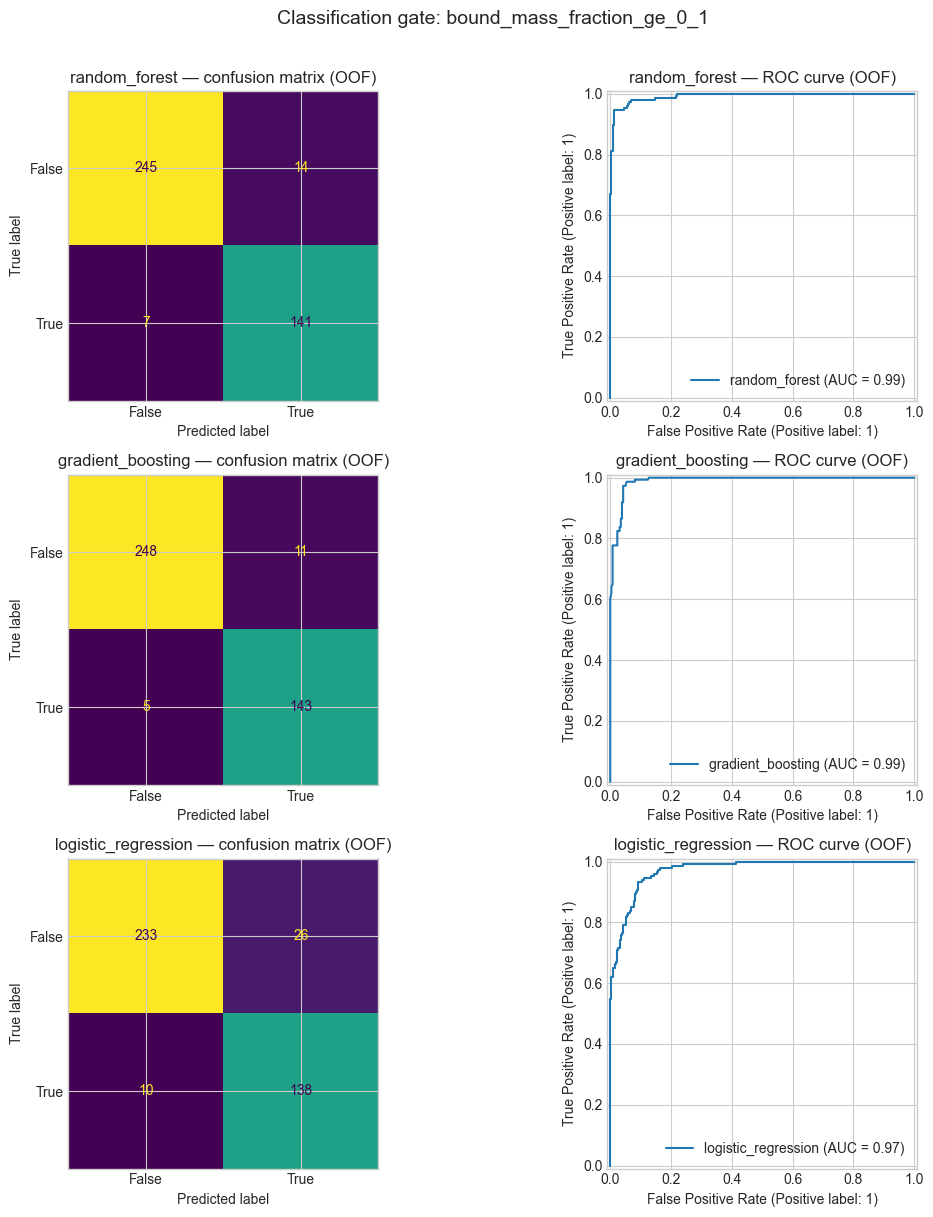

In [7]:
fig, axes = plt.subplots(len(clf_preds), 2, figsize=(12, 4 * len(clf_preds)))
if len(clf_preds) == 1:
    axes = np.array([axes])

for row_idx, model_name in enumerate(clf_metrics_df["model"]):
    pf = clf_preds[model_name]
    ConfusionMatrixDisplay.from_predictions(
        pf["actual"], pf["predicted"],
        ax=axes[row_idx, 0], colorbar=False,
    )
    axes[row_idx, 0].set_title(f"{model_name} — confusion matrix (OOF)")

    RocCurveDisplay.from_predictions(
        pf["actual"], pf["score"],
        ax=axes[row_idx, 1],
        name=model_name,
    )
    axes[row_idx, 1].set_title(f"{model_name} — ROC curve (OOF)")

fig.suptitle(f"Classification gate: {CLASSIFICATION_TARGET}", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

In [8]:
clf_saved = []
for model_name, fitted in clf_trained.items():
    out = SAVE_DIR / f"{CLASSIFICATION_TARGET}__with_fof_linking_length__{model_name}.pkl"
    with out.open("wb") as fh:
        pickle.dump(fitted, fh)
    clf_saved.append(str(out))
    print(f"Saved: {out}")

pd.DataFrame({"saved_classifier": clf_saved})

Saved: ml/bound_outcomes/notebook_demo/bound_mass_fraction_ge_0_1__with_fof_linking_length__logistic_regression.pkl
Saved: ml/bound_outcomes/notebook_demo/bound_mass_fraction_ge_0_1__with_fof_linking_length__random_forest.pkl
Saved: ml/bound_outcomes/notebook_demo/bound_mass_fraction_ge_0_1__with_fof_linking_length__gradient_boosting.pkl


,saved_classifier
0,ml/bound_outcomes/notebook_demo/bound_mass_fra...
1,ml/bound_outcomes/notebook_demo/bound_mass_fra...
2,ml/bound_outcomes/notebook_demo/bound_mass_fra...


---
## 6 · Regression · Fragmentation targets

Three targets describing how the body fragments:

| Target | Description |
|---|---|
| `n_fragments` | Total number of fragments produced |
| `largest_fragment_mass_kg` | Mass of the single largest fragment (bound or unbound) |
| `total_fragment_mass_kg` | Total mass across all fragments |

In [9]:
frag_all_rows = []
frag_all_preds = {}
frag_all_trained = {}

for target in FRAGMENTATION_TARGETS:
    y_reg = pd.to_numeric(df[target], errors="coerce")
    print(f"\n── Target: {target}  (n={y_reg.notna().sum()}, mean={y_reg.mean():.3e}) ──")

    regressors = build_regressors()
    target_rows, target_preds, target_trained = [], {}, {}

    for model_name, pipeline in regressors.items():
        print(f"   {model_name} …")
        row, preds, fitted = evaluate_regressor(model_name, pipeline, X, y_reg, groups)
        row["target"] = target
        target_rows.append(row)
        target_preds[model_name] = preds
        target_trained[model_name] = fitted

    frag_all_rows.extend(target_rows)
    frag_all_preds[target] = target_preds
    frag_all_trained[target] = target_trained

frag_metrics_df = pd.DataFrame(frag_all_rows)[["target", "model", "r2", "mae", "n", "train_r2", "train_mae"]]
frag_metrics_df


── Target: n_fragments  (n=407, mean=4.660e+02) ──
   ridge …
   random_forest …


   gradient_boosting …

── Target: largest_fragment_mass_kg  (n=407, mean=2.756e+19) ──
   ridge …
   random_forest …


   gradient_boosting …

── Target: total_fragment_mass_kg  (n=407, mean=8.641e+19) ──
   ridge …
   random_forest …


   gradient_boosting …


,target,model,r2,mae,n,train_r2,train_mae
0,n_fragments,ridge,0.189517,4.550733e+02,407,0.231295,4.445600e+02
1,n_fragments,random_forest,0.773396,1.771937e+02,407,0.933118,8.471089e+01
2,n_fragments,gradient_boosting,0.758240,2.052129e+02,407,0.875602,1.409975e+02
3,largest_fragment_mass_kg,ridge,0.372569,2.074825e+19,407,0.444863,1.991535e+19
4,largest_fragment_mass_kg,random_forest,0.435798,9.344613e+18,407,0.951632,3.171516e+18
5,largest_fragment_mass_kg,gradient_boosting,0.441760,1.109488e+19,407,0.976814,4.602724e+18
6,total_fragment_mass_kg,ridge,0.333487,4.375334e+19,407,0.410525,4.192933e+19
7,total_fragment_mass_kg,random_forest,0.972782,3.667809e+18,407,0.999664,5.876305e+17
8,total_fragment_mass_kg,gradient_boosting,0.999301,1.025396e+18,407,0.999738,7.463670e+17


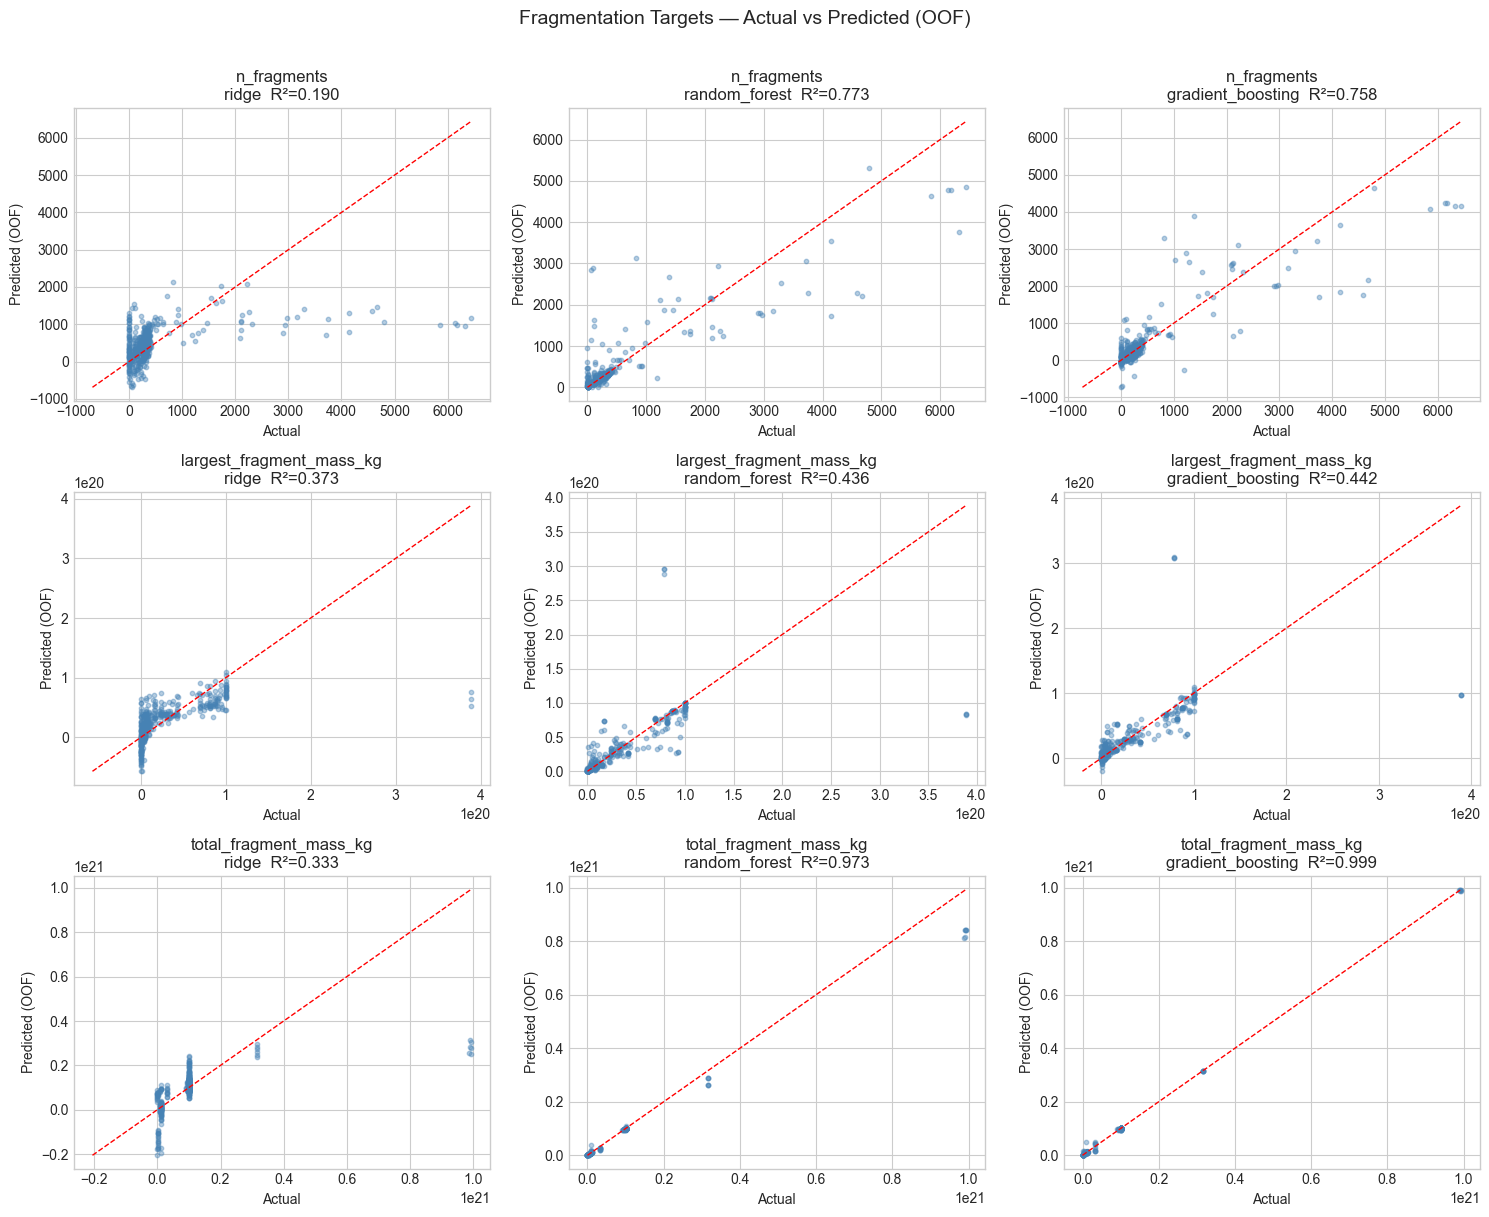

In [10]:
n_models = 3  # ridge, random_forest, gradient_boosting
n_targets = len(FRAGMENTATION_TARGETS)

fig, axes = plt.subplots(n_targets, n_models, figsize=(5 * n_models, 4 * n_targets))

for t_idx, target in enumerate(FRAGMENTATION_TARGETS):
    preds_dict = frag_all_preds[target]
    for m_idx, model_name in enumerate(preds_dict):
        ax = axes[t_idx, m_idx]
        pf = preds_dict[model_name]
        ax.scatter(pf["actual"], pf["predicted"], alpha=0.4, s=10, color="steelblue")
        lims = [min(pf["actual"].min(), pf["predicted"].min()),
                max(pf["actual"].max(), pf["predicted"].max())]
        ax.plot(lims, lims, "r--", lw=1, label="perfect")
        r2 = frag_metrics_df.query("target==@target and model==@model_name")["r2"].values
        ax.set_title(f"{target}\n{model_name}  R²={r2[0]:.3f}" if len(r2) else f"{target}\n{model_name}")
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted (OOF)")

fig.suptitle("Fragmentation Targets — Actual vs Predicted (OOF)", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

In [11]:
frag_saved = []
for target, model_dict in frag_all_trained.items():
    for model_name, fitted in model_dict.items():
        out = SAVE_DIR / f"{target}__with_fof_linking_length__{model_name}.pkl"
        with out.open("wb") as fh:
            pickle.dump(fitted, fh)
        frag_saved.append(str(out))
        print(f"Saved: {out}")

pd.DataFrame({"saved_fragmentation_regressor": frag_saved})

Saved: ml/bound_outcomes/notebook_demo/n_fragments__with_fof_linking_length__ridge.pkl
Saved: ml/bound_outcomes/notebook_demo/n_fragments__with_fof_linking_length__random_forest.pkl
Saved: ml/bound_outcomes/notebook_demo/n_fragments__with_fof_linking_length__gradient_boosting.pkl
Saved: ml/bound_outcomes/notebook_demo/largest_fragment_mass_kg__with_fof_linking_length__ridge.pkl
Saved: ml/bound_outcomes/notebook_demo/largest_fragment_mass_kg__with_fof_linking_length__random_forest.pkl
Saved: ml/bound_outcomes/notebook_demo/largest_fragment_mass_kg__with_fof_linking_length__gradient_boosting.pkl
Saved: ml/bound_outcomes/notebook_demo/total_fragment_mass_kg__with_fof_linking_length__ridge.pkl
Saved: ml/bound_outcomes/notebook_demo/total_fragment_mass_kg__with_fof_linking_length__random_forest.pkl
Saved: ml/bound_outcomes/notebook_demo/total_fragment_mass_kg__with_fof_linking_length__gradient_boosting.pkl


,saved_fragmentation_regressor
0,ml/bound_outcomes/notebook_demo/n_fragments__w...
1,ml/bound_outcomes/notebook_demo/n_fragments__w...
2,ml/bound_outcomes/notebook_demo/n_fragments__w...
3,ml/bound_outcomes/notebook_demo/largest_fragme...
4,ml/bound_outcomes/notebook_demo/largest_fragme...
5,ml/bound_outcomes/notebook_demo/largest_fragme...
6,ml/bound_outcomes/notebook_demo/total_fragment...
7,ml/bound_outcomes/notebook_demo/total_fragment...
8,ml/bound_outcomes/notebook_demo/total_fragment...


---
## 7 · Regression · Bound targets

Four targets describing the gravitationally bound material:

| Target | Description |
|---|---|
| `bound_mass_fraction` | Fraction of target mass that is bound (continuous, 0–1) |
| `bound_fragment_count` | Number of bound fragments |
| `largest_bound_fragment_mass_kg` | Mass of the largest bound fragment |
| `average_bound_fragment_mass_kg` | Mean mass per bound fragment |

In [12]:
bound_all_rows = []
bound_all_preds = {}
bound_all_trained = {}

for target in BOUND_TARGETS:
    y_reg = pd.to_numeric(df[target], errors="coerce")
    print(f"\n── Target: {target}  (n={y_reg.notna().sum()}, mean={y_reg.mean():.3e}) ──")

    regressors = build_regressors()
    target_rows, target_preds, target_trained = [], {}, {}

    for model_name, pipeline in regressors.items():
        print(f"   {model_name} …")
        row, preds, fitted = evaluate_regressor(model_name, pipeline, X, y_reg, groups)
        row["target"] = target
        target_rows.append(row)
        target_preds[model_name] = preds
        target_trained[model_name] = fitted

    bound_all_rows.extend(target_rows)
    bound_all_preds[target] = target_preds
    bound_all_trained[target] = target_trained

bound_metrics_df = pd.DataFrame(bound_all_rows)[["target", "model", "r2", "mae", "n", "train_r2", "train_mae"]]
bound_metrics_df


── Target: bound_mass_fraction  (n=407, mean=7.910e-02) ──
   ridge …
   random_forest …


   gradient_boosting …

── Target: bound_fragment_count  (n=407, mean=9.700e+01) ──
   ridge …
   random_forest …


   gradient_boosting …

── Target: largest_bound_fragment_mass_kg  (n=407, mean=1.576e+18) ──
   ridge …
   random_forest …


   gradient_boosting …

── Target: average_bound_fragment_mass_kg  (n=225, mean=2.004e+17) ──
   ridge …
   random_forest …


   gradient_boosting …


,target,model,r2,mae,n,train_r2,train_mae
0,bound_mass_fraction,ridge,0.672508,4.350587e-02,407,0.691494,4.246159e-02
1,bound_mass_fraction,random_forest,0.897127,1.839384e-02,407,0.979205,7.500462e-03
2,bound_mass_fraction,gradient_boosting,0.884015,2.275038e-02,407,0.953129,1.401470e-02
3,bound_fragment_count,ridge,0.172761,1.189445e+02,407,0.242932,1.145371e+02
4,bound_fragment_count,random_forest,0.490485,6.591151e+01,407,0.816254,3.377611e+01
5,bound_fragment_count,gradient_boosting,0.443222,8.429041e+01,407,0.751561,5.315386e+01
6,largest_bound_fragment_mass_kg,ridge,0.240329,1.708979e+18,407,0.333005,1.637066e+18
7,largest_bound_fragment_mass_kg,random_forest,0.824166,5.675631e+17,407,0.980169,2.244678e+17
8,largest_bound_fragment_mass_kg,gradient_boosting,0.796414,7.682351e+17,407,0.976922,3.988761e+17
9,average_bound_fragment_mass_kg,ridge,0.520709,1.022620e+17,225,0.643106,9.297300e+16


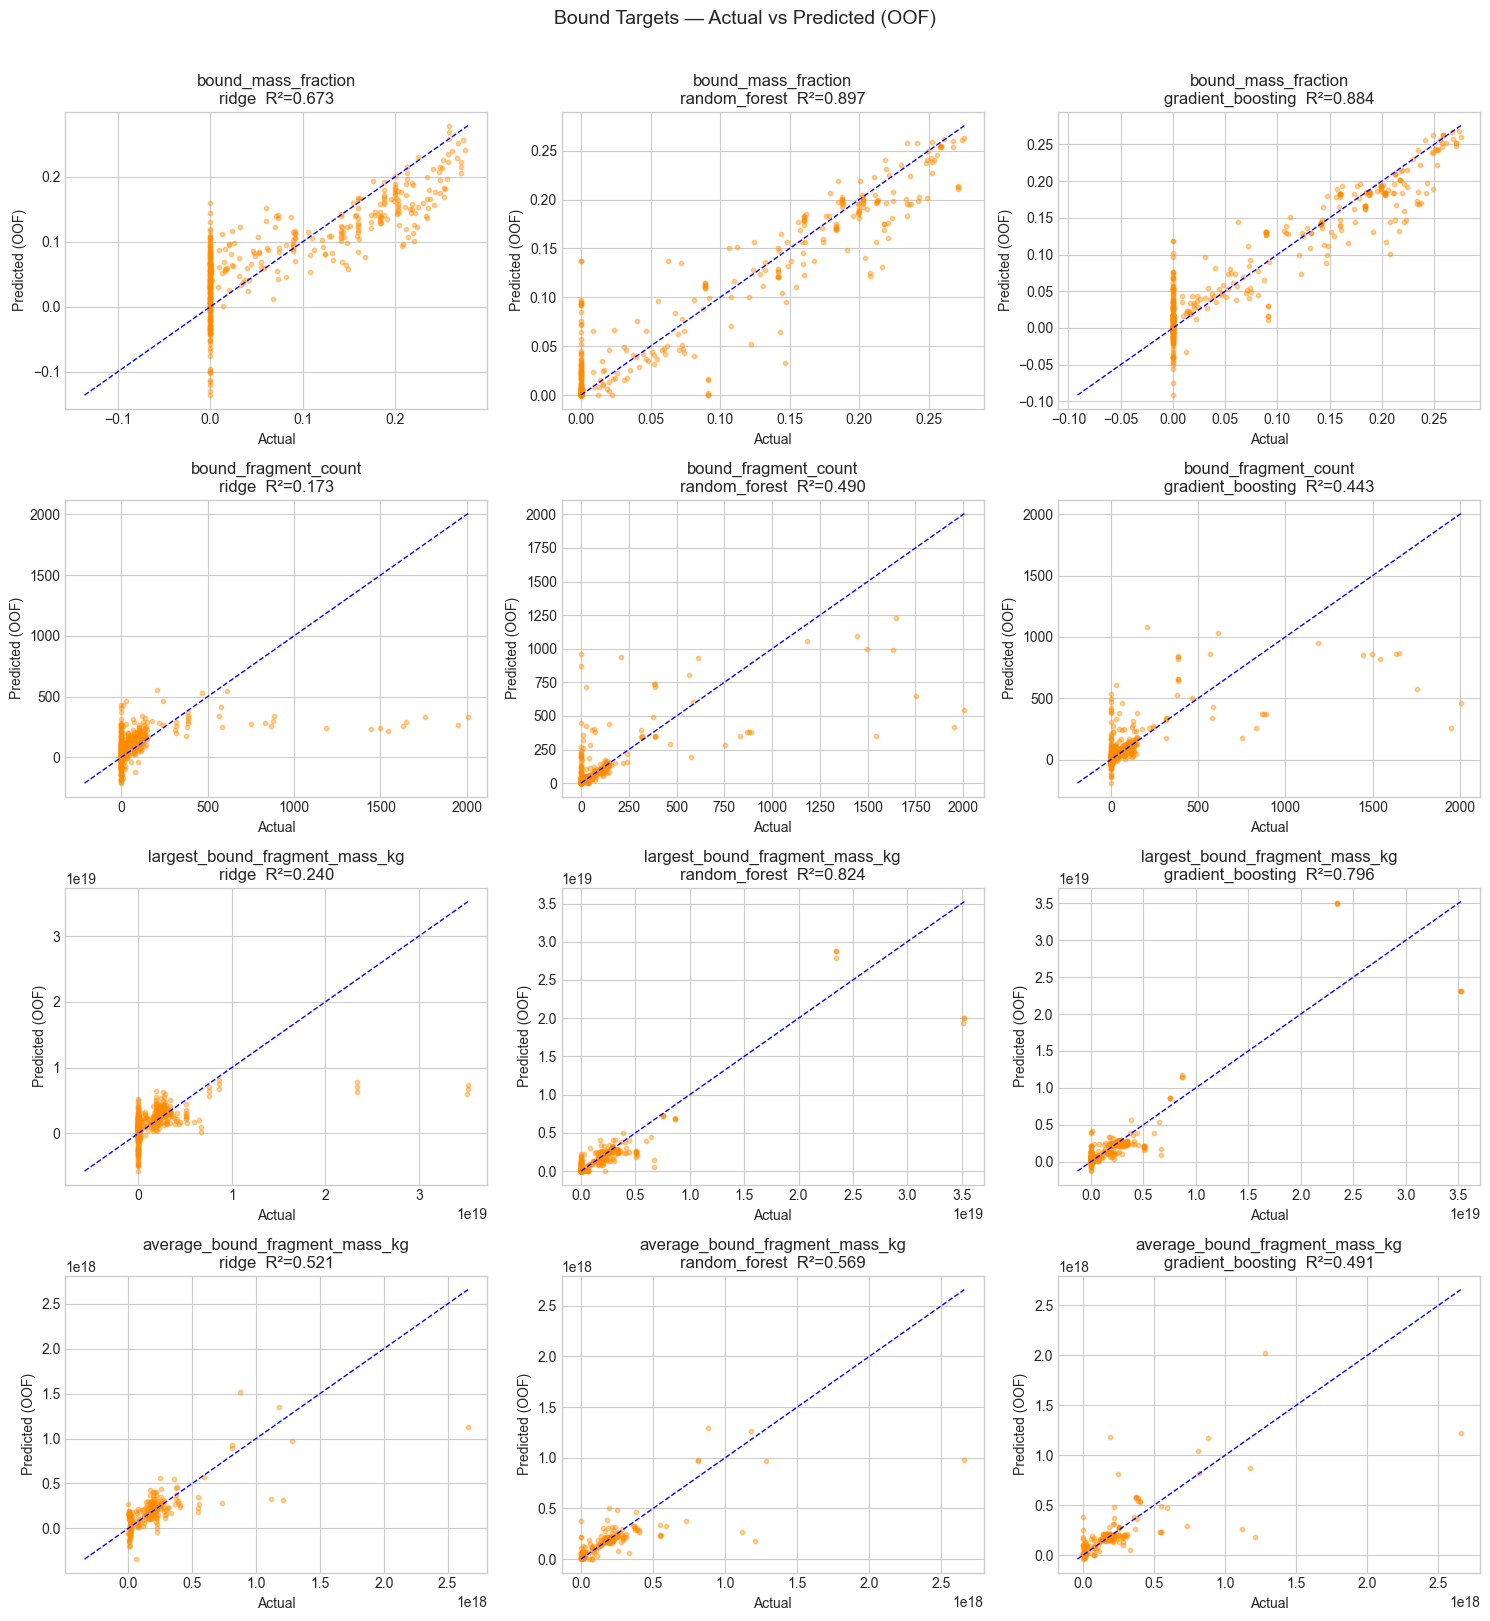

In [13]:
n_models = 3
n_targets = len(BOUND_TARGETS)

fig, axes = plt.subplots(n_targets, n_models, figsize=(5 * n_models, 4 * n_targets))

for t_idx, target in enumerate(BOUND_TARGETS):
    preds_dict = bound_all_preds[target]
    for m_idx, model_name in enumerate(preds_dict):
        ax = axes[t_idx, m_idx]
        pf = preds_dict[model_name]
        ax.scatter(pf["actual"], pf["predicted"], alpha=0.4, s=10, color="darkorange")
        lims = [min(pf["actual"].min(), pf["predicted"].min()),
                max(pf["actual"].max(), pf["predicted"].max())]
        ax.plot(lims, lims, "b--", lw=1, label="perfect")
        r2 = bound_metrics_df.query("target==@target and model==@model_name")["r2"].values
        ax.set_title(f"{target}\n{model_name}  R²={r2[0]:.3f}" if len(r2) else f"{target}\n{model_name}")
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted (OOF)")

fig.suptitle("Bound Targets — Actual vs Predicted (OOF)", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

In [14]:
bound_saved = []
for target, model_dict in bound_all_trained.items():
    for model_name, fitted in model_dict.items():
        out = SAVE_DIR / f"{target}__with_fof_linking_length__{model_name}.pkl"
        with out.open("wb") as fh:
            pickle.dump(fitted, fh)
        bound_saved.append(str(out))
        print(f"Saved: {out}")

pd.DataFrame({"saved_bound_regressor": bound_saved})

Saved: ml/bound_outcomes/notebook_demo/bound_mass_fraction__with_fof_linking_length__ridge.pkl
Saved: ml/bound_outcomes/notebook_demo/bound_mass_fraction__with_fof_linking_length__random_forest.pkl
Saved: ml/bound_outcomes/notebook_demo/bound_mass_fraction__with_fof_linking_length__gradient_boosting.pkl
Saved: ml/bound_outcomes/notebook_demo/bound_fragment_count__with_fof_linking_length__ridge.pkl
Saved: ml/bound_outcomes/notebook_demo/bound_fragment_count__with_fof_linking_length__random_forest.pkl
Saved: ml/bound_outcomes/notebook_demo/bound_fragment_count__with_fof_linking_length__gradient_boosting.pkl
Saved: ml/bound_outcomes/notebook_demo/largest_bound_fragment_mass_kg__with_fof_linking_length__ridge.pkl
Saved: ml/bound_outcomes/notebook_demo/largest_bound_fragment_mass_kg__with_fof_linking_length__random_forest.pkl
Saved: ml/bound_outcomes/notebook_demo/largest_bound_fragment_mass_kg__with_fof_linking_length__gradient_boosting.pkl
Saved: ml/bound_outcomes/notebook_demo/average_bo

,saved_bound_regressor
0,ml/bound_outcomes/notebook_demo/bound_mass_fra...
1,ml/bound_outcomes/notebook_demo/bound_mass_fra...
2,ml/bound_outcomes/notebook_demo/bound_mass_fra...
3,ml/bound_outcomes/notebook_demo/bound_fragment...
4,ml/bound_outcomes/notebook_demo/bound_fragment...
5,ml/bound_outcomes/notebook_demo/bound_fragment...
6,ml/bound_outcomes/notebook_demo/largest_bound_...
7,ml/bound_outcomes/notebook_demo/largest_bound_...
8,ml/bound_outcomes/notebook_demo/largest_bound_...
9,ml/bound_outcomes/notebook_demo/average_bound_...


---
## 8 · Summary dashboard

Consolidated view of all OOF results across classification and regression tasks.

In [15]:
print("=" * 70)
print("CLASSIFICATION GATE")
print("=" * 70)
display(clf_metrics_df[["model", "balanced_accuracy", "f1", "roc_auc"]].round(3))

print()
print("=" * 70)
print("FRAGMENTATION REGRESSION (OOF R²)")
print("=" * 70)
display(frag_metrics_df.pivot(index="model", columns="target", values="r2").round(3))

print()
print("=" * 70)
print("BOUND REGRESSION (OOF R²)")
print("=" * 70)
display(bound_metrics_df.pivot(index="model", columns="target", values="r2").round(3))

CLASSIFICATION GATE


,model,balanced_accuracy,f1,roc_auc
1,random_forest,0.949,0.931,0.992
2,gradient_boosting,0.962,0.947,0.990
0,logistic_regression,0.916,0.885,0.973



FRAGMENTATION REGRESSION (OOF R²)


target,largest_fragment_mass_kg,n_fragments,total_fragment_mass_kg
model,,,
gradient_boosting,0.442,0.758,0.999
random_forest,0.436,0.773,0.973
ridge,0.373,0.190,0.333



BOUND REGRESSION (OOF R²)


target,average_bound_fragment_mass_kg,bound_fragment_count,bound_mass_fraction,largest_bound_fragment_mass_kg
model,,,,
gradient_boosting,0.491,0.443,0.884,0.796
random_forest,0.569,0.490,0.897,0.824
ridge,0.521,0.173,0.673,0.240


---
## Notes

- **Classification gate** uses `bound_mass_fraction_ge_0_1` as the sole binary target. If AUC > 0.80, targets `has_any_bound_mass` and `BMF ≥ 10%` are redundant.
- **Fragmentation targets** (`n_fragments`, `largest_fragment_mass_kg`, `total_fragment_mass_kg`) describe the overall disruption.
- **Bound targets** (`bound_mass_fraction`, `bound_fragment_count`, `largest_bound_fragment_mass_kg`, `average_bound_fragment_mass_kg`) quantify what remains gravitationally bound.
- `largest_fragment_mass_kg` is engineered as `max(largest_bound_fragment_mass_kg, largest_unbound_fragment_mass_kg)` since the raw data does not store it directly.
- `average_bound_fragment_mass_kg` is `bound_mass_kg / bound_fragment_count`; rows with zero bound fragments are excluded (NaN).
- All regression evaluations use grouped cross-validation split by `physical_file` to avoid data leakage from related simulations.